# Wykrywanie wadliwych detali – klasyfikacja zdjęć

Zadanie 5, wariant 2. Sieć ResNet-18 (transfer learning) uczy się rozróżniać dwie klasy: **dobry** i **wadliwy**.

Kroki:
1. dane i podział na zbiory,
2. przygotowanie zdjęć i augmentacja,
3. model,
4. uczenie,
5. ocena na zbiorze testowym,
6. strefa „niepewny".

In [ ]:
import copy
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# stałe ziarno losowości, żeby wyniki dało się powtórzyć
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Urządzenie:", device)

Urządzenie: cpu


## 1. Dane

Publiczny zbiór zdjęć odlewów (wirniki pomp) z Kaggle. Używam folderu z **oryginalnymi** zdjęciami 512×512 (ok. 1300 sztuk).
Drugi folder w tym zbiorze zawiera ich sztucznie powielone kopie, więc go pomijam: te same detale trafiłyby do zbioru uczącego i testowego, co zawyżyłoby wynik.

In [ ]:
os.environ["KAGGLEHUB_CACHE"] = "dane"   # dane lądują w folderze obok notebooka
import kagglehub

folder = Path(kagglehub.dataset_download(
    "ravirajsinh45/real-life-industrial-dataset-of-casting-product"))
folder = folder / "casting_512x512" / "casting_512x512"

dobre = sorted((folder / "ok_front").glob("*.jpeg"))
wadliwe = sorted((folder / "def_front").glob("*.jpeg"))

sciezki = dobre + wadliwe
etykiety = [0] * len(dobre) + [1] * len(wadliwe)   # 0 = dobry, 1 = wadliwy
NAZWY = ["dobry", "wadliwy"]

print("dobre:", len(dobre), "| wadliwe:", len(wadliwe))

dobre: 519 | wadliwe: 781


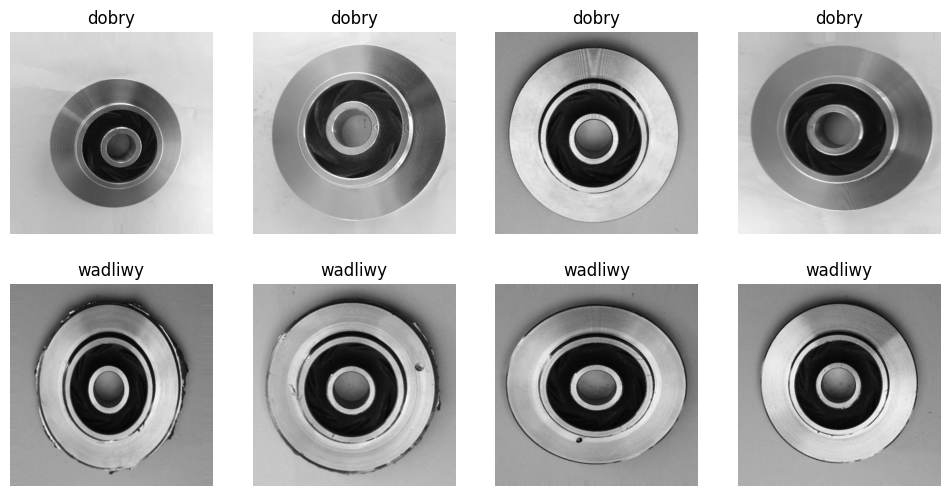

In [ ]:
fig, osie = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    osie[0, i].imshow(Image.open(dobre[i]), cmap="gray")
    osie[0, i].set_title("dobry")
    osie[1, i].imshow(Image.open(wadliwe[i]), cmap="gray")
    osie[1, i].set_title("wadliwy")
for os_ in osie.ravel():
    os_.axis("off")
plt.show()

### Podział: 70% uczący, 15% walidacyjny, 15% testowy

`stratify` pilnuje, żeby w każdym zbiorze była ta sama proporcja dobrych do wadliwych.

In [ ]:
X_ucz, X_reszta, y_ucz, y_reszta = train_test_split(
    sciezki, etykiety, test_size=0.30, stratify=etykiety, random_state=SEED)
X_wal, X_test, y_wal, y_test = train_test_split(
    X_reszta, y_reszta, test_size=0.50, stratify=y_reszta, random_state=SEED)

for nazwa, y in [("uczący", y_ucz), ("walidacyjny", y_wal), ("testowy", y_test)]:
    print(f"{nazwa:12s} razem: {len(y):4d} | dobre: {y.count(0):3d} | wadliwe: {y.count(1):3d}")

uczący       razem:  910 | dobre: 363 | wadliwe: 547
walidacyjny  razem:  195 | dobre:  78 | wadliwe: 117
testowy      razem:  195 | dobre:  78 | wadliwe: 117


## 2. Przygotowanie zdjęć i augmentacja

Każde zdjęcie jest zmniejszane do 224×224 i normalizowane (tak, jak oczekuje ResNet).
Zdjęcia uczące dodatkowo losowo obracam, odbijam i zmieniam im jasność – model przy każdej epoce widzi trochę inną wersję.

In [ ]:
normalizacja = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

tf_uczenie = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalizacja,
])

tf_ocena = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalizacja,
])


class Detale(Dataset):
    def __init__(self, sciezki, etykiety, tf):
        self.sciezki, self.etykiety, self.tf = sciezki, etykiety, tf

    def __len__(self):
        return len(self.sciezki)

    def __getitem__(self, i):
        zdjecie = Image.open(self.sciezki[i]).convert("RGB")
        return self.tf(zdjecie), self.etykiety[i]


BATCH = 32
dl_ucz = DataLoader(Detale(X_ucz, y_ucz, tf_uczenie), batch_size=BATCH, shuffle=True)
dl_wal = DataLoader(Detale(X_wal, y_wal, tf_ocena), batch_size=BATCH)
dl_test = DataLoader(Detale(X_test, y_test, tf_ocena), batch_size=BATCH)

## 3. Model

ResNet-18 z wagami wyuczonymi na ImageNet. Podmieniam tylko ostatnią warstwę: zamiast 1000 klas są 2.

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# rzadsza klasa dostaje większą wagę, żeby model jej nie ignorował
liczba = np.bincount(y_ucz)
wagi_klas = torch.tensor(len(y_ucz) / (2 * liczba), dtype=torch.float32).to(device)
print("wagi klas (dobry, wadliwy):", wagi_klas.cpu().numpy().round(2))

funkcja_straty = nn.CrossEntropyLoss(weight=wagi_klas)
optymalizator = torch.optim.Adam(model.parameters(), lr=1e-4)

wagi klas (dobry, wadliwy): [1.25 0.83]


## 4. Uczenie

W każdej epoce model przechodzi przez cały zbiór uczący paczkami po 32 zdjęcia i po każdej paczce poprawia wagi.
Po epoce sprawdzam go na zbiorze walidacyjnym (bez uczenia) i zapamiętuję najlepszą wersję.

In [ ]:
def jedna_epoka(dl, uczenie):
    model.train() if uczenie else model.eval()
    suma_straty, trafione = 0.0, 0
    with torch.set_grad_enabled(uczenie):
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            wynik = model(x)
            strata = funkcja_straty(wynik, y)
            if uczenie:
                optymalizator.zero_grad()
                strata.backward()      # jak zmienić wagi, żeby błąd spadł
                optymalizator.step()   # mały krok w tę stronę
            suma_straty += strata.item() * len(y)
            trafione += (wynik.argmax(1) == y).sum().item()
    return suma_straty / len(dl.dataset), trafione / len(dl.dataset)


EPOKI = 6
historia = {"ucz": [], "wal": []}
najlepsza_strata, najlepsze_wagi = float("inf"), None

for epoka in range(1, EPOKI + 1):
    strata_ucz, dokl_ucz = jedna_epoka(dl_ucz, uczenie=True)
    strata_wal, dokl_wal = jedna_epoka(dl_wal, uczenie=False)
    historia["ucz"].append(strata_ucz)
    historia["wal"].append(strata_wal)
    print(f"epoka {epoka}: strata ucz. {strata_ucz:.3f} | strata wal. {strata_wal:.3f} "
          f"| dokładność wal. {dokl_wal:.3f}")
    if strata_wal < najlepsza_strata:
        najlepsza_strata = strata_wal
        najlepsze_wagi = copy.deepcopy(model.state_dict())

model.load_state_dict(najlepsze_wagi)

epoka 1: strata ucz. 0.357 | strata wal. 0.214 | dokładność wal. 0.923


epoka 2: strata ucz. 0.105 | strata wal. 0.056 | dokładność wal. 0.995


epoka 3: strata ucz. 0.078 | strata wal. 0.073 | dokładność wal. 0.974


epoka 4: strata ucz. 0.044 | strata wal. 0.045 | dokładność wal. 0.979


epoka 5: strata ucz. 0.051 | strata wal. 0.039 | dokładność wal. 0.990


epoka 6: strata ucz. 0.053 | strata wal. 0.021 | dokładność wal. 0.995


<All keys matched successfully>

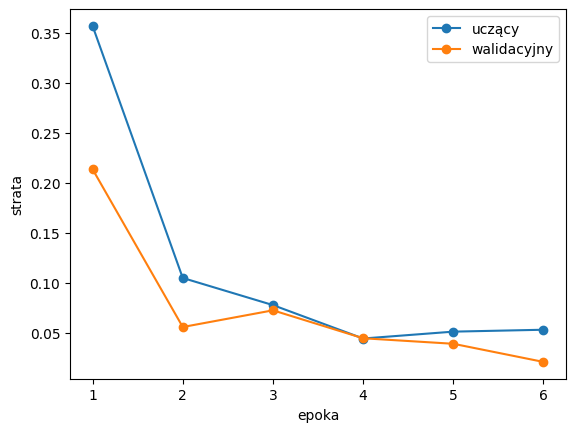

In [ ]:
plt.plot(range(1, EPOKI + 1), historia["ucz"], marker="o", label="uczący")
plt.plot(range(1, EPOKI + 1), historia["wal"], marker="o", label="walidacyjny")
plt.xlabel("epoka")
plt.ylabel("strata")
plt.legend()
plt.show()

## 5. Ocena na zbiorze testowym

Model tych zdjęć nie widział ani przy uczeniu, ani przy wyborze najlepszej wersji.

czułość (ile wad wykryto):          0.983
precyzja (ile odrzutów słusznych):  1.000
F1:                                 0.991


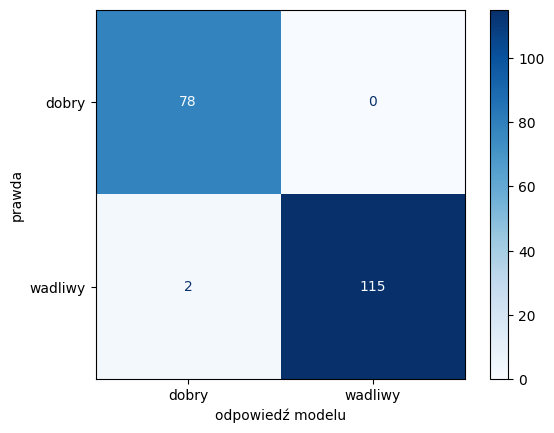

In [ ]:
model.eval()
prawd_wady = []
with torch.no_grad():
    for x, _ in dl_test:
        p = torch.softmax(model(x.to(device)), dim=1)[:, 1]   # prawdopodobieństwo klasy „wadliwy"
        prawd_wady.extend(p.cpu().numpy())

prawd_wady = np.array(prawd_wady)
y_test = np.array(y_test)
przewidziane = (prawd_wady >= 0.5).astype(int)

print(f"czułość (ile wad wykryto):          {recall_score(y_test, przewidziane):.3f}")
print(f"precyzja (ile odrzutów słusznych):  {precision_score(y_test, przewidziane):.3f}")
print(f"F1:                                 {f1_score(y_test, przewidziane):.3f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, przewidziane), display_labels=NAZWY).plot(cmap="Blues")
plt.xlabel("odpowiedź modelu")
plt.ylabel("prawda")
plt.show()

## 6. Strefa „niepewny"

Zamiast jednego progu 50% stosuję dwa. Detale, których model nie jest pewny, idą do sprawdzenia przez człowieka.
Progi 20% / 80% są przykładowe.

zdjęć testowych:                  195
decyzja automatyczna:             193
do sprawdzenia przez człowieka:   2
błędy w decyzjach automatycznych: 2
  w tym przepuszczone wady:       2


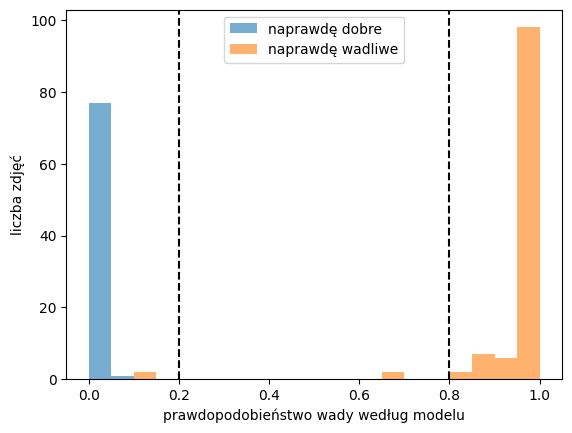

In [ ]:
DOLNY, GORNY = 0.20, 0.80

niepewne = (prawd_wady > DOLNY) & (prawd_wady < GORNY)
pewne = ~niepewne
bledy_pewne = (przewidziane[pewne] != y_test[pewne]).sum()
przepuszczone_wady = ((prawd_wady <= DOLNY) & (y_test == 1)).sum()

print(f"zdjęć testowych:                  {len(y_test)}")
print(f"decyzja automatyczna:             {pewne.sum()}")
print(f"do sprawdzenia przez człowieka:   {niepewne.sum()}")
print(f"błędy w decyzjach automatycznych: {bledy_pewne}")
print(f"  w tym przepuszczone wady:       {przepuszczone_wady}")

plt.hist(prawd_wady[y_test == 0], bins=20, range=(0, 1), alpha=0.6, label="naprawdę dobre")
plt.hist(prawd_wady[y_test == 1], bins=20, range=(0, 1), alpha=0.6, label="naprawdę wadliwe")
plt.axvline(DOLNY, color="k", linestyle="--")
plt.axvline(GORNY, color="k", linestyle="--")
plt.xlabel("prawdopodobieństwo wady według modelu")
plt.ylabel("liczba zdjęć")
plt.legend()
plt.show()

### Zdjęcia, których model był najmniej pewny

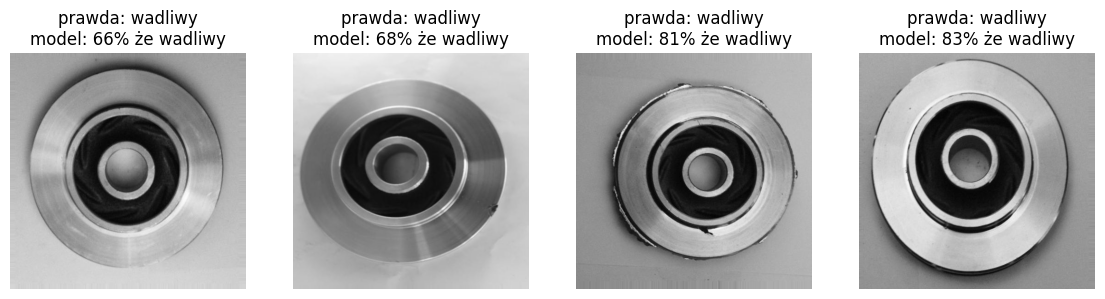

In [ ]:
kolejnosc = np.argsort(np.abs(prawd_wady - 0.5))[:4]   # najbliżej 50%

fig, osie = plt.subplots(1, 4, figsize=(14, 4))
for os_, i in zip(osie, kolejnosc):
    os_.imshow(Image.open(X_test[i]), cmap="gray")
    os_.set_title(f"prawda: {NAZWY[y_test[i]]}\nmodel: {prawd_wady[i]:.0%} że wadliwy")
    os_.axis("off")
plt.show()